Loading Data, Cleaning, and Basic Visualizations

In [5]:
#Import Modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h1>HRSA Mental Health Dataset Availability</h1>

In [14]:
hrsa_df = pd.read_csv("BCD_HPSA_FCT_DET_MH.csv")

hrsa_df.head()

C:\Users\ConnerMorgan\AppData\Local\Temp\ipykernel_6788\3337126284.py:1: DtypeWarning: Columns (0: BHCMIS Organization Identification Number) have mixed types. Specify dtype option on import or set low_memory=False.
  hrsa_df = pd.read_csv("BCD_HPSA_FCT_DET_MH.csv")


,HPSA Name,HPSA ID,Designation Type,HPSA Discipline Class,HPSA Score,Primary State Abbreviation,HPSA Status,HPSA Designation Date,HPSA Designation Last Update Date,Metropolitan Indicator,...,Rural Status Code,State Abbreviation,State and County Federal Information Processing Standard Code,State FIPS Code,State Name,U.S. - Mexico Border 100 Kilometer Indicator,U.S. - Mexico Border County Indicator,Data Warehouse Record Create Date,Data Warehouse Record Create Date Text,Unnamed: 64
0,Low Income - St. John/St. Thomas,7789997804,HPSA Population,Mental Health,0,VI,Withdrawn,10/20/2005,10/30/2008,Non-Metropolitan,...,R,VI,78020,78,U.S. Virgin Islands,N,N,04/16/2026,2026/04/16,NaN
1,Low Income - St. John/St. Thomas,7789997804,HPSA Population,Mental Health,0,VI,Withdrawn,10/20/2005,10/30/2008,Non-Metropolitan,...,R,VI,78030,78,U.S. Virgin Islands,N,N,04/16/2026,2026/04/16,NaN
2,ST THOMAS EAST END MEDICAL CENTER CORPORATION,7789997803,Federally Qualified Health Center,Mental Health,23,VI,Designated,10/26/2002,09/22/2025,Non-Metropolitan,...,R,VI,78030,78,U.S. Virgin Islands,N,N,04/16/2026,2026/04/16,NaN
3,FREDERIKSTED HEALTH CARE INC,7789997802,Federally Qualified Health Center,Mental Health,22,VI,Designated,10/26/2002,09/22/2025,Non-Metropolitan,...,R,VI,78010,78,U.S. Virgin Islands,N,N,04/16/2026,2026/04/16,NaN
4,St. John Island,7788997414,High Needs Geographic HPSA,Mental Health,12,VI,Designated,09/02/2022,09/02/2022,Unknown,...,R,VI,78020,78,U.S. Virgin Islands,N,N,04/16/2026,2026/04/16,NaN


In [ ]:
# remove empty columns
hrsa_df = hrsa_df.loc[:, ~hrsa_df.columns.str.contains('^Unnamed')]

# filter for Ohio
hrsa_ohio = hrsa_df[hrsa_df['state'] == 'OH'].copy()

# check data
hrsa_ohio.head()


,fips,county,state,hpsa_score,population_in_shortage,provider_shortage
7737,39145,"Scioto County, OH",OH,21,45973.0,NaN
7738,39049,"Franklin County, OH",OH,15,478624.0,NaN
7739,39103,"Medina County, OH",OH,11,589461.0,NaN
7740,39153,"Summit County, OH",OH,20,96775.0,NaN
7741,39015,"Brown County, OH",OH,15,182368.0,NaN


In [32]:
hrsa_county_ohio = hrsa_ohio.groupby(['fips', 'county', 'state']).agg({
    'hpsa_score': 'mean',
    'population_in_shortage': 'sum',
    'provider_shortage': 'sum'
}).reset_index()

hrsa_county_ohio.head(10)

,fips,county,state,hpsa_score,population_in_shortage,provider_shortage
0,39001,"Adams County, OH",OH,16.000000,390606.0,3.8700
1,39003,"Allen County, OH",OH,10.333333,449466.0,6.3714
2,39007,"Ashtabula County, OH",OH,13.333333,231618.0,5.7742
3,39009,"Athens County, OH",OH,16.666667,179640.0,5.7473
4,39011,"Auglaize County, OH",OH,9.500000,229299.0,5.2314
5,39013,"Belmont County, OH",OH,15.750000,87540.0,6.1500
6,39015,"Brown County, OH",OH,14.600000,725622.0,2.1500
7,39017,"Butler County, OH",OH,17.000000,77063.0,0.0000
8,39019,"Carroll County, OH",OH,16.000000,117600.0,7.5900
9,39021,"Champaign County, OH",OH,12.000000,83850.0,2.5150


First Visualization:
This bar chart shows the top 10 counties in Ohio with the highest mental health provider shortages. The visualization highlights significant variation in access to mental health services across counties. Some counties experience substantially higher shortages, indicating potential gaps in service availability and unequal distribution of mental health resources.

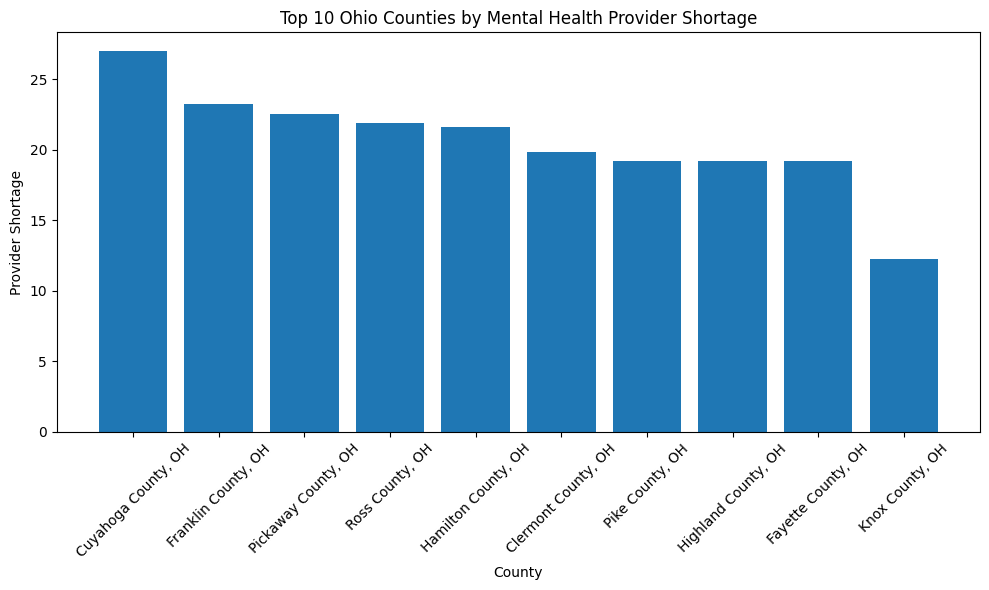

In [33]:

# Sort and take top 10 counties
top_shortage = hrsa_county_ohio.sort_values(
    by='provider_shortage', ascending=False
).head(10)

# Create bar chart
plt.figure(figsize=(10,6))
plt.bar(top_shortage['county'], top_shortage['provider_shortage'])

plt.title('Top 10 Ohio Counties by Mental Health Provider Shortage')
plt.xlabel('County')
plt.ylabel('Provider Shortage')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h1>CDC</h1>